In [8]:
from pathlib import Path
import random
from PIL import Image
import matplotlib.pyplot as plt
from datasets import load_dataset, Image as HFImage

In [9]:
parquet_dir = (Path.cwd().parent / "dataset1" / "data").resolve()
# print("Parquet dir:", parquet_dir)
files = sorted(str(p) for p in parquet_dir.rglob("*.parquet"))
print("Znaleziono plików parquet:", len(files))
if not files:
    raise SystemExit("Nie znaleziono *.parquet w ../dataset1/data/")

Znaleziono plików parquet: 7


In [ ]:
ds = load_dataset("parquet", data_files=files, split="train")
try:
    ds = ds.cast_column("image", HFImage())
except Exception as e:
    print("Uwaga: nie udało się zrzutować kolumny 'image' na obraz:", e)
    raise

print(ds)
print("Klucze:", ds.column_names)

Generating train split: 103250 examples [00:43, 2383.72 examples/s]


Dataset({
    features: ['title', 'artist', 'date', 'genre', 'style', 'description', 'filename', 'image', 'embeddings_pca512', 'resnet50_non_robust_feats', 'resnet50_robust_feats'],
    num_rows: 103250
})
Przykładowe klucze: ['title', 'artist', 'date', 'genre', 'style', 'description', 'filename', 'image', 'embeddings_pca512', 'resnet50_non_robust_feats', 'resnet50_robust_feats']


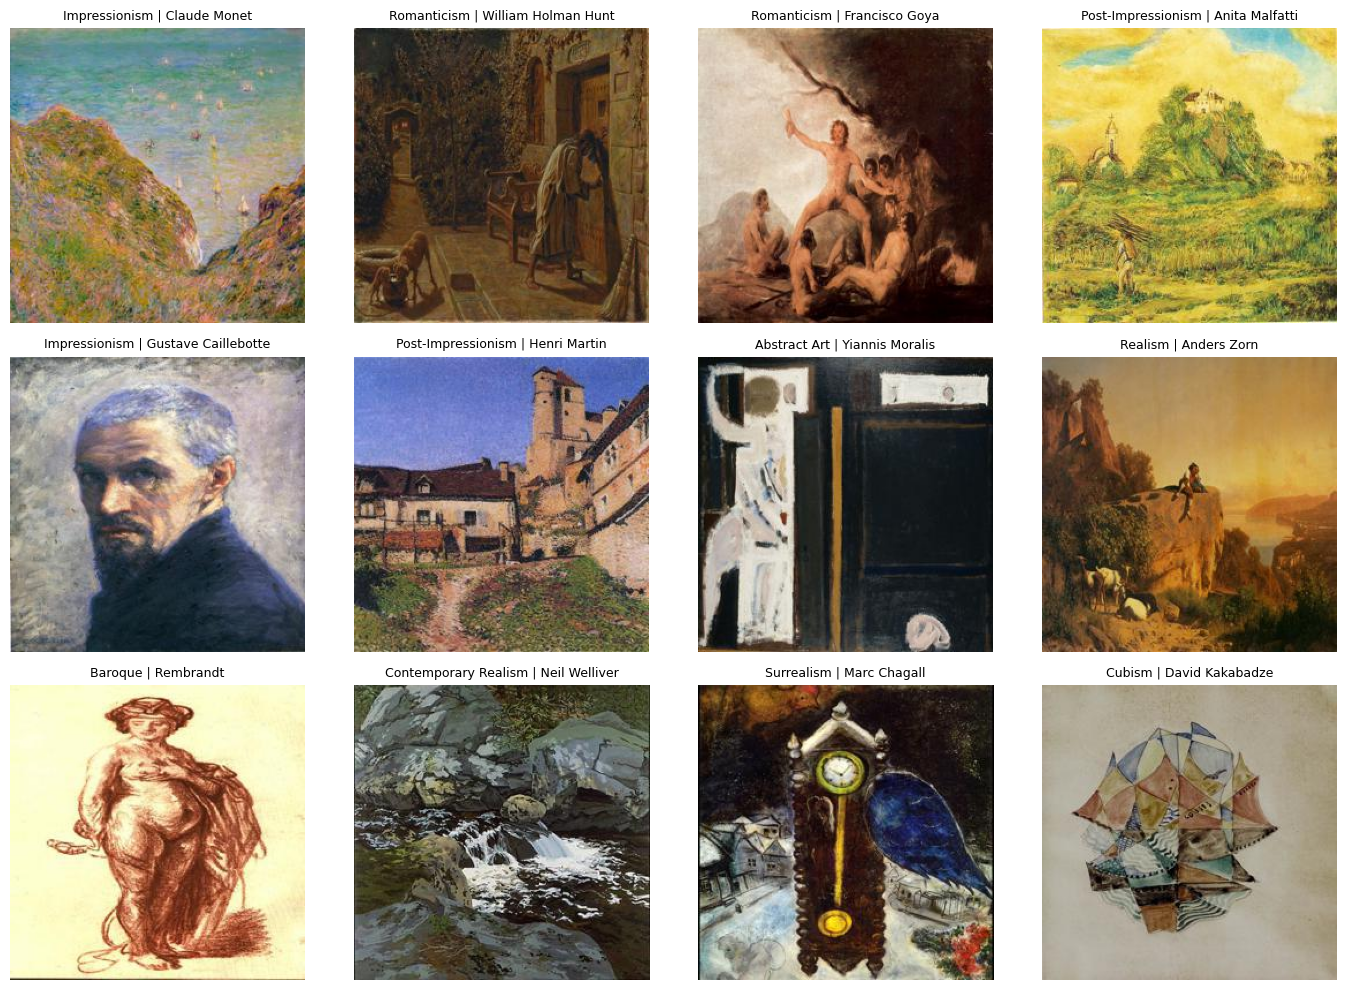

In [7]:
n_show = 12
idxs = random.sample(range(len(ds)), min(n_show, len(ds)))

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for ax, i in zip(axes, idxs):
    rec = ds[i]
    img = rec["image"]      # PIL.Image po cast_column
    ax.imshow(img)
    title_parts = []
    if "style" in rec and rec["style"]:
        title_parts.append(str(rec["style"]))
    if "artist" in rec and rec["artist"]:
        title_parts.append(str(rec["artist"]))
    ax.set_title(" | ".join(title_parts)[:60], fontsize=9)
    ax.axis("off")

for k in range(len(idxs), len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()